# Distributed tiling results

A look at the tiles produced by `distributed_tiling.py`: loaded straight from the `.npy` files it wrote, no re-reading from the source scene.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

TILES_DIR = Path("../data/sentinel2_tiles")

n_tiles = len(list(TILES_DIR.glob("*.npy")))
print(f"{n_tiles} tiles available in {TILES_DIR}")

5130 tiles available in ../data/sentinel2_tiles


## A grid of neighboring tiles

Load a contiguous 8x8 block back from disk and reassemble it, to check the tiles line up correctly with their neighbors -- and to have something visual to show.

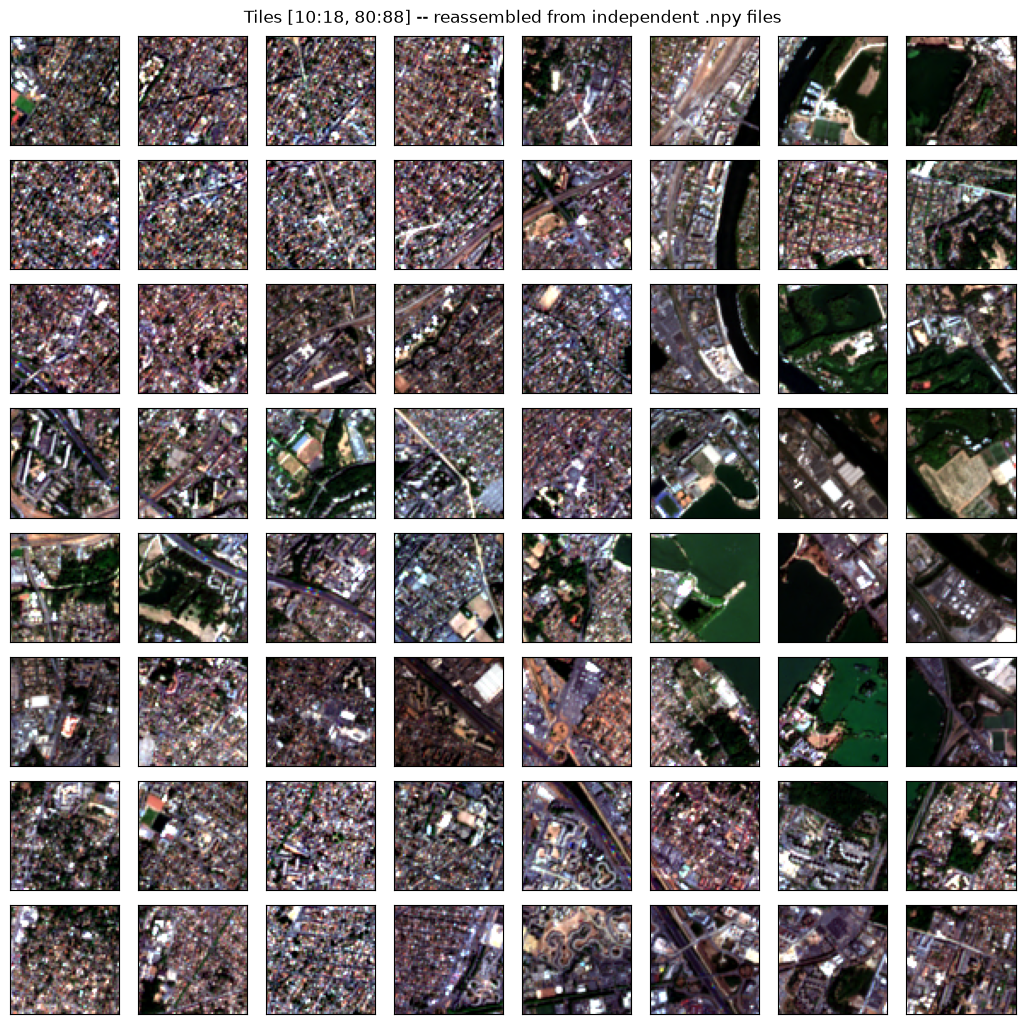

In [2]:
GRID_SIZE = 8
ROW_START, COL_START = 10, 80


def stretch(band, low=2, high=98):
    lo, hi = np.percentile(band, [low, high])
    return np.clip((band.astype(np.float32) - lo) / (hi - lo), 0, 1)


fig, axes = plt.subplots(GRID_SIZE, GRID_SIZE, figsize=(GRID_SIZE * 1.3, GRID_SIZE * 1.3))

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        row, col = ROW_START + i, COL_START + j
        tile = np.load(TILES_DIR / f"tile_{row:03d}_{col:03d}.npy")
        tile_stretched = np.stack([stretch(tile[..., c]) for c in range(3)], axis=-1)

        ax = axes[i, j]
        ax.imshow(tile_stretched)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle(f"Tiles [{ROW_START}:{ROW_START+GRID_SIZE}, {COL_START}:{COL_START+GRID_SIZE}] -- reassembled from independent .npy files")
plt.tight_layout()
plt.show()